# Agreement Experiments

This notebook tracks the current agreement experiment as batch outputs arrive. It joins model outputs back to local samples and grammars, scores exact match against both the canonical target and the full set of licensed targets, and summarizes results by agreement condition, grammar size, and sentence depth.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import json
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import pyrootutils

from IPython.display import display

PROJECT_ROOT = pyrootutils.find_root(indicator=".project-root")
DATA_DIR = PROJECT_ROOT / "data"
BATCHES_DIR = PROJECT_ROOT / "batches"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
FIGURES_DIR = NOTEBOOKS_DIR / "figures"
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))
EXP_NAME = "agreement"
EXP_DATA_DIR = DATA_DIR / f"{EXP_NAME}_exp"
EXP_BATCH_DIR = BATCHES_DIR / f"{EXP_NAME}_exp"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GRAMMAR_LIST = EXP_DATA_DIR / f"{EXP_NAME}_grammars.txt"
assert GRAMMAR_LIST.exists(), GRAMMAR_LIST
assert EXP_DATA_DIR.exists(), EXP_DATA_DIR
assert EXP_BATCH_DIR.exists(), EXP_BATCH_DIR


## Define aesthetics

In [2]:
import aesthetics as aes  # noqa: F401

sns = aes.sns
plt = aes.plt
mtick = aes.mtick

aes.PALETTE_METRICS

PALETTE_AGREEMENT = aes.darken(
    {
        "NoAgr → NoAgr": sns.color_palette("Dark2", n_colors=4)[0],
        "NoAgr → Agr": sns.color_palette("Dark2", n_colors=4)[1],
        "Agr → NoAgr": sns.color_palette("Dark2", n_colors=4)[2],
        "Agr → Agr": sns.color_palette("Dark2", n_colors=4)[3],
    },
    by=0.25,
)


## Load grammars and samples

In [3]:
with open(GRAMMAR_LIST) as f:
    grammar_ids = [line.strip() for line in f if line.strip()]


def load_grammar(grammar_id: str) -> dict:
    with open(EXP_DATA_DIR / f"grammar_{grammar_id}.json") as f:
        grammar = json.load(f)
    meta = grammar.get("agreement_metadata", {})
    a_enabled = bool(meta.get("a", {}).get("config", {}).get("enabled", False))
    b_enabled = bool(meta.get("b", {}).get("config", {}).get("enabled", False))
    return {
        "grammar_name": grammar_id,
        "n_words": grammar.get("n_words"),
        "n_rules": grammar.get("n_rules"),
        "agreement_enabled_a": a_enabled,
        "agreement_enabled_b": b_enabled,
        "agreement_condition": f"{'Agr' if a_enabled else 'NoAgr'} → {'Agr' if b_enabled else 'NoAgr'}",
    }


def extract_json_field(line: str, start_marker: str, end_markers: list[str]):
    start = line.index(start_marker) + len(start_marker)
    end = min(line.index(marker, start) for marker in end_markers if marker in line[start:])
    return json.loads(line[start:end])


def load_sample_manifest(grammar_id: str) -> pd.DataFrame:
    rows = []
    with open(EXP_DATA_DIR / f"samples_{grammar_id}.jsonl") as f:
        for sample_id, line in enumerate(f):
            has_features = '"subject_features":' in line
            rows.append(
                {
                    "grammar_name": grammar_id,
                    "sample_id": str(sample_id),
                    "left_phonetic": extract_json_field(line, '"left_phonetic": ', [', "right":']),
                    "right_phonetic": extract_json_field(
                        line,
                        '"right_phonetic": ',
                        [', "possible_right":', ', "left_tree":'],
                    ),
                    "depth": extract_json_field(
                        line,
                        '"depth": ',
                        [', "subject_features":', ', "grammar_name":'],
                    ),
                    "subject_features": extract_json_field(
                        line,
                        '"subject_features": ',
                        [', "verb_features":'],
                    ) if has_features else {},
                    "verb_features": extract_json_field(
                        line,
                        '"verb_features": ',
                        [', "possible_right":'],
                    ) if has_features else {},
                }
            )
    return pd.DataFrame(rows)


grammars_df = pd.DataFrame([load_grammar(grammar_id) for grammar_id in grammar_ids])
samples_df = pd.concat(
    [load_sample_manifest(grammar_id) for grammar_id in grammar_ids], ignore_index=True
)
samples_df["input_length"] = samples_df["left_phonetic"].str.split().str.len()
samples_df["target_length"] = samples_df["right_phonetic"].str.split().str.len()
samples_df["subject_person"] = samples_df["subject_features"].apply(
    lambda x: x.get("person") if isinstance(x, dict) else None
)
samples_df["subject_number"] = samples_df["subject_features"].apply(
    lambda x: x.get("number") if isinstance(x, dict) else None
)
samples_df = samples_df.merge(grammars_df, on="grammar_name", how="left")

print(f"Grammars: {len(grammars_df)}")
print(f"Samples: {len(samples_df)}")
display(
    grammars_df.groupby(["agreement_condition", "n_words"])
    .size()
    .rename("n_grammars")
    .reset_index()
    .head(12)
)
display(
    samples_df.groupby(["agreement_condition", "depth"])
    .size()
    .rename("n_samples")
    .reset_index()
    .head(12)
)


Grammars: 56
Samples: 6720


,agreement_condition,n_words,n_grammars
0,Agr → Agr,56,2
1,Agr → Agr,102,2
2,Agr → Agr,192,2
3,Agr → Agr,1812,2
4,Agr → Agr,9012,2
5,Agr → Agr,13512,2
6,Agr → Agr,18012,2
7,Agr → NoAgr,56,2
8,Agr → NoAgr,102,2
9,Agr → NoAgr,192,2


,agreement_condition,depth,n_samples
0,Agr → Agr,0,280
1,Agr → Agr,1,280
2,Agr → Agr,2,280
3,Agr → Agr,3,280
4,Agr → Agr,4,280
5,Agr → Agr,5,280
6,Agr → NoAgr,0,280
7,Agr → NoAgr,1,280
8,Agr → NoAgr,2,280
9,Agr → NoAgr,3,280


In [4]:
samples_df.groupby("agreement_condition").agg(
    samples=("sample_id", "size"),
    mean_input_length=("input_length", "mean"),
    mean_target_length=("target_length", "mean"),
).round(2).reset_index()


,agreement_condition,samples,mean_input_length,mean_target_length
0,Agr → Agr,1680,15.40,15.00
1,Agr → NoAgr,1680,15.01,14.66
2,NoAgr → Agr,1680,15.08,15.02
3,NoAgr → NoAgr,1680,15.52,16.35


## Load available batch outputs

In [5]:
CUSTOM_ID_RE = re.compile(
    r"^(?P<grammar_name>[0-9a-f]+)-(?P<input_hash>[0-9a-f]+)-sample-(?P<sample_id>\d+)$"
)
ANSWER_RE = re.compile(
    r"final\s*answer\s*(?::|-|—)?\s*(?:is\s*)?([^\n]+)", re.IGNORECASE | re.DOTALL
)


def fuzzy_model(model: str) -> str:
    return re.sub(r"-\d{4}-\d{2}-\d{2}$", "", model or "")


def extract_answer(model_response: str | None) -> str | None:
    if not model_response:
        return None
    matches = ANSWER_RE.findall(model_response)
    if not matches:
        return None
    answer = matches[-1].strip()
    answer = re.sub(r"[^\w\s]", "", answer, flags=re.UNICODE).strip()
    return answer or None


def parse_usage(body: dict) -> tuple[int | None, int | None, int | None]:
    usage = body.get("usage", {}) or {}
    if "prompt_tokens" in usage:
        return (
            usage.get("prompt_tokens"),
            usage.get("completion_tokens"),
            usage.get("total_tokens"),
        )
    return (
        usage.get("promptTokens"),
        usage.get("completionTokens"),
        usage.get("totalTokens"),
    )


def load_outputs(batch_dir: Path) -> pd.DataFrame:
    rows = []
    for path in sorted(batch_dir.glob("*_output.jsonl")):
        with open(path) as f:
            for line in f:
                item = json.loads(line)
                body = (item.get("response") or {}).get("body") or {}
                message = None
                choices = body.get("choices") or []
                if choices:
                    message = ((choices[0] or {}).get("message") or {}).get("content")
                prompt_tokens, completion_tokens, total_tokens = parse_usage(body)
                match = CUSTOM_ID_RE.match(item.get("custom_id", ""))
                if not match:
                    continue
                row = {
                    "batch_file": path.name,
                    "batch_id": path.name.replace("_output.jsonl", ""),
                    "custom_id": item.get("custom_id"),
                    "grammar_name": match.group("grammar_name"),
                    "input_hash": match.group("input_hash"),
                    "sample_id": match.group("sample_id"),
                    "model": body.get("model"),
                    "fuzzy_model": fuzzy_model(body.get("model", "")),
                    "model_response": message,
                    "model_answer": extract_answer(message),
                    "status_code": (item.get("response") or {}).get("status_code"),
                    "error": item.get("error"),
                    "prompt_tokens": prompt_tokens,
                    "completion_tokens": completion_tokens,
                    "total_tokens": total_tokens,
                }
                rows.append(row)
    return pd.DataFrame(rows)


outputs_df = load_outputs(EXP_BATCH_DIR)
print(f"Output rows loaded: {len(outputs_df)}")
if len(outputs_df):
    display(
        outputs_df.groupby(["batch_file", "fuzzy_model"])
        .size()
        .rename("n_rows")
        .reset_index()
    )
else:
    print("No batch output files found yet.")


Output rows loaded: 6486


,batch_file,fuzzy_model,n_rows
0,batch_69b2ed92bc7081908206626e8b94ce44_output....,gpt-5-nano,2809
1,batch_69b2f3aa8d8c81909410f508c013b22f_output....,gpt-5-nano,868
2,batch_69b3122f52f881908f332e1e104515c5_output....,gpt-5-mini,2809


## Merge outputs with samples

In [6]:
def json_string_array_contains(array_text: str, value: str | None) -> bool:
    if not value:
        return False
    needle = json.dumps(value, ensure_ascii=False)
    return any(
        token in array_text
        for token in (
            f"[{needle}]",
            f"[{needle}, ",
            f", {needle}, ",
            f", {needle}]",
        )
    )


def count_json_string_array_items(array_text: str) -> int:
    array_text = array_text.strip()
    if array_text == "[]":
        return 0
    return array_text.count('", "') + 1


def extract_possible_right_phonetic_array(line: str) -> str:
    start_marker = '"possible_right_phonetic": '
    end_markers = [', "agreement_ok":', ', "left_tree":', ', "grammar_name":']
    start = line.index(start_marker) + len(start_marker)
    end = min(line.index(marker, start) for marker in end_markers if marker in line[start:])
    return line[start:end]


def load_reference_stats_for_outputs(outputs_df: pd.DataFrame) -> pd.DataFrame:
    if outputs_df.empty:
        return pd.DataFrame(columns=["grammar_name", "sample_id", "reference_count", "is_ambiguous", "exact_match_any"])

    outputs_df = outputs_df.copy()
    outputs_df["reference_count"] = np.nan
    outputs_df["is_ambiguous"] = False
    outputs_df["exact_match_any"] = False

    needed = {}
    for idx, row in outputs_df.iterrows():
        needed.setdefault(row["grammar_name"], {}).setdefault(row["sample_id"], []).append(idx)

    for grammar_name, sample_map in needed.items():
        sample_path = EXP_DATA_DIR / f"samples_{grammar_name}.jsonl"
        with open(sample_path) as f:
            for sample_idx, line in enumerate(f):
                sample_id = str(sample_idx)
                if sample_id not in sample_map:
                    continue
                array_text = extract_possible_right_phonetic_array(line)
                ref_count = count_json_string_array_items(array_text)
                for row_idx in sample_map[sample_id]:
                    answer = outputs_df.at[row_idx, "model_answer"]
                    outputs_df.at[row_idx, "reference_count"] = ref_count
                    outputs_df.at[row_idx, "is_ambiguous"] = ref_count > 1
                    outputs_df.at[row_idx, "exact_match_any"] = json_string_array_contains(array_text, answer)

    return outputs_df


merged_df = outputs_df.merge(
    samples_df,
    on=["grammar_name", "sample_id"],
    how="left",
    validate="many_to_one",
) if len(outputs_df) else pd.DataFrame()

if len(merged_df):
    merged_df = merged_df.drop_duplicates(subset=["batch_id", "custom_id"]).copy()
    merged_df = load_reference_stats_for_outputs(merged_df)
    merged_df["has_answer"] = merged_df["model_answer"].notna()
    merged_df["exact_match_canonical"] = merged_df.apply(
        lambda row: row["model_answer"] == row["right_phonetic"] if row["model_answer"] else False,
        axis=1,
    )
    merged_df["length_delta"] = merged_df.apply(
        lambda row: len(row["model_answer"].split()) - row["target_length"] if row["model_answer"] else np.nan,
        axis=1,
    )
    merged_df["ambiguity_bonus"] = merged_df["exact_match_any"] & ~merged_df["exact_match_canonical"]
    completion_rate = len(merged_df) / len(samples_df)
    print(f"Completed rows: {len(merged_df)} / {len(samples_df)} ({completion_rate:.1%})")
    display(merged_df.head())
else:
    print("No outputs merged yet.")


Completed rows: 6486 / 6720 (96.5%)


,batch_file,batch_id,custom_id,grammar_name,input_hash,sample_id,model,fuzzy_model,model_response,model_answer,...,agreement_enabled_a,agreement_enabled_b,agreement_condition,reference_count,is_ambiguous,exact_match_any,has_answer,exact_match_canonical,length_delta,ambiguity_bonus
0,batch_69b2ed92bc7081908206626e8b94ce44_output....,batch_69b2ed92bc7081908206626e8b94ce44,179d4d1c734893f7-8d9610-sample-0,179d4d1c734893f7,8d9610,0,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: bayqat quprolhas faqgac bayqat k...,bayqat quprolhas faqgac bayqat karbagtac,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0.0,False
1,batch_69b2ed92bc7081908206626e8b94ce44_output....,batch_69b2ed92bc7081908206626e8b94ce44,179d4d1c734893f7-8d9610-sample-1,179d4d1c734893f7,8d9610,1,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: cactebxub pejxirpap zazyep qupro...,cactebxub pejxirpap zazyep quprolhas,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0.0,False
2,batch_69b2ed92bc7081908206626e8b94ce44_output....,batch_69b2ed92bc7081908206626e8b94ce44,179d4d1c734893f7-8d9610-sample-2,179d4d1c734893f7,8d9610,2,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: zazyep havlamqidhaz vetfuphup pe...,zazyep havlamqidhaz vetfuphup pejxirpap zazyep...,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0.0,False
3,batch_69b2ed92bc7081908206626e8b94ce44_output....,batch_69b2ed92bc7081908206626e8b94ce44,179d4d1c734893f7-8d9610-sample-3,179d4d1c734893f7,8d9610,3,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: karbagtac nusyojtaz bayqat qupro...,karbagtac nusyojtaz bayqat quprolhas,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0.0,False
4,batch_69b2ed92bc7081908206626e8b94ce44_output....,batch_69b2ed92bc7081908206626e8b94ce44,179d4d1c734893f7-8d9610-sample-4,179d4d1c734893f7,8d9610,4,gpt-5-nano-2025-08-07,gpt-5-nano,Final answer: nimgoh nusyojtaz bayqat bof,nimgoh nusyojtaz bayqat bof,...,False,False,NoAgr → NoAgr,1.0,False,True,True,True,0.0,False


## Progress snapshot

In [7]:
if len(merged_df):
    progress_by_cell = (
        merged_df.groupby(["agreement_condition", "n_words", "depth"])
        .size()
        .rename("completed")
        .reset_index()
    )
    target_by_cell = (
        samples_df.groupby(["agreement_condition", "n_words", "depth"])
        .size()
        .rename("expected")
        .reset_index()
    )
    progress_df = target_by_cell.merge(
        progress_by_cell, on=["agreement_condition", "n_words", "depth"], how="left"
    ).fillna({"completed": 0})
    progress_df["completed"] = progress_df["completed"].astype(int)
    progress_df["pct_complete"] = progress_df["completed"] / progress_df["expected"]
    display(
        progress_df.sort_values(["agreement_condition", "n_words", "depth"]).head(20)
    )
else:
    progress_df = pd.DataFrame()
    print("No progress to report yet.")


,agreement_condition,n_words,depth,expected,completed,pct_complete
0,Agr → Agr,56,0,40,0,0.0
1,Agr → Agr,56,1,40,0,0.0
2,Agr → Agr,56,2,40,0,0.0
3,Agr → Agr,56,3,40,0,0.0
4,Agr → Agr,56,4,40,0,0.0
5,Agr → Agr,56,5,40,0,0.0
6,Agr → Agr,102,0,40,0,0.0
7,Agr → Agr,102,1,40,0,0.0
8,Agr → Agr,102,2,40,0,0.0
9,Agr → Agr,102,3,40,0,0.0


## Accuracy metrics

In [8]:
if len(merged_df):
    from difflib import SequenceMatcher

    try:
        import evaluate
    except ImportError:
        evaluate = None

    try:
        from nltk.translate import bleu as nltk_bleu
        from nltk.translate.bleu_score import SmoothingFunction
    except ImportError:
        nltk_bleu = None
        SmoothingFunction = None

    def bow_match(row) -> bool:
        if row["model_answer"] is None or row["right_phonetic"] is None:
            return False
        return sorted(row["model_answer"].split()) == sorted(row["right_phonetic"].split())

    def edit_similarity(row) -> float:
        pred = row["model_answer"] or ""
        ref = row["right_phonetic"] or ""
        return SequenceMatcher(None, pred, ref).ratio()

    def bleu_score(row) -> float:
        if nltk_bleu is None:
            return np.nan
        refs = [row["right_phonetic"].split()] if row["right_phonetic"] else [[]]
        hyp = row["model_answer"].split() if row["model_answer"] else []
        smoothing = SmoothingFunction().method7 if SmoothingFunction is not None else None
        return nltk_bleu(references=refs, hypothesis=hyp, smoothing_function=smoothing)

    merged_df["bow_match"] = merged_df.apply(bow_match, axis=1)
    merged_df["edit_similarity"] = merged_df.apply(edit_similarity, axis=1)
    merged_df["bleu"] = merged_df.apply(bleu_score, axis=1)

    if evaluate is not None:
        chrf = evaluate.load("chrf")
        merged_df["chrF++"] = [
            chrf.compute(
                predictions=[pred or ""],
                references=[[ref or ""]],
                beta=2,
                word_order=2,
            )["score"] / 100.0
            for pred, ref in zip(merged_df["model_answer"], merged_df["right_phonetic"])
        ]
    else:
        merged_df["chrF++"] = np.nan

    summary_by_model = (
        merged_df.groupby(["fuzzy_model"])
        .agg(
            rows=("custom_id", "size"),
            answered=("has_answer", "sum"),
            exact_match_canonical=("exact_match_canonical", "mean"),
            exact_match_any=("exact_match_any", "mean"),
            bow_match=("bow_match", "mean"),
            edit_similarity=("edit_similarity", "mean"),
            bleu=("bleu", "mean"),
            chrf_pp=("chrF++", "mean"),
            ambiguity_bonus=("ambiguity_bonus", "mean"),
            mean_prompt_tokens=("prompt_tokens", "mean"),
            mean_completion_tokens=("completion_tokens", "mean"),
        )
        .reset_index()
    )
    for col in [
        "exact_match_canonical",
        "exact_match_any",
        "bow_match",
        "edit_similarity",
        "bleu",
        "chrf_pp",
        "ambiguity_bonus",
    ]:
        summary_by_model[col] = (100 * summary_by_model[col]).round(2)
    summary_by_model
else:
    print("No outputs available for scoring yet.")


In [9]:
if len(merged_df):
    by_condition = (
        merged_df.groupby(["agreement_condition", "fuzzy_model"])
        .agg(
            rows=("custom_id", "size"),
            exact_match_canonical=("exact_match_canonical", "mean"),
            exact_match_any=("exact_match_any", "mean"),
            bow_match=("bow_match", "mean"),
            edit_similarity=("edit_similarity", "mean"),
            bleu=("bleu", "mean"),
            chrf_pp=("chrF++", "mean"),
            ambiguity_rate=("is_ambiguous", "mean"),
            ambiguity_bonus=("ambiguity_bonus", "mean"),
        )
        .reset_index()
    )
    for col in [
        "exact_match_canonical",
        "exact_match_any",
        "bow_match",
        "edit_similarity",
        "bleu",
        "chrf_pp",
        "ambiguity_rate",
        "ambiguity_bonus",
    ]:
        by_condition[col] = (100 * by_condition[col]).round(2)
    display(by_condition.sort_values(["fuzzy_model", "agreement_condition"]))

    metrics_for_plot = [
        ("exact_match_any", "Exact Match"),
        ("bow_match", "Bag of Words"),
        ("bleu", "BLEU Score"),
        ("chrF++", "chrF++"),
    ]

    plot_model_candidates = sorted(merged_df["fuzzy_model"].dropna().unique())
    PLOT_MODEL = plot_model_candidates[0] if plot_model_candidates else None
    print(f"Plotting model: {PLOT_MODEL}")

    plot_source_df = merged_df[merged_df["fuzzy_model"] == PLOT_MODEL].copy()
    plot_depth_df = plot_source_df.melt(
        id_vars=["agreement_condition", "depth", "n_words"],
        value_vars=[col for col, _ in metrics_for_plot],
        var_name="metric_key",
        value_name="match_value",
    )
    plot_depth_df["match_type"] = plot_depth_df["metric_key"].replace(
        {col: name for col, name in metrics_for_plot}
    )

    plot_size_df = plot_depth_df.copy()
    plot_depth_df["match_value"] = plot_depth_df["match_value"].astype(float)
    plot_size_df["match_value"] = plot_size_df["match_value"].astype(float)
else:
    plot_depth_df = pd.DataFrame()
    plot_size_df = pd.DataFrame()
    PLOT_MODEL = None


,agreement_condition,fuzzy_model,rows,exact_match_canonical,exact_match_any,bow_match,edit_similarity,bleu,chrf_pp,ambiguity_rate,ambiguity_bonus
1,NoAgr → Agr,gpt-5-mini,1129,20.55,31.62,20.55,86.01,68.56,76.87,100.0,11.07
3,NoAgr → NoAgr,gpt-5-mini,1680,59.94,59.94,59.94,91.27,89.33,87.54,0.0,0.00
0,Agr → NoAgr,gpt-5-nano,868,23.85,23.85,23.85,77.71,64.97,70.20,0.0,0.00
2,NoAgr → Agr,gpt-5-nano,1129,3.72,6.11,3.72,55.82,22.08,41.77,100.0,2.39
4,NoAgr → NoAgr,gpt-5-nano,1680,37.56,37.56,37.62,67.37,59.11,61.35,0.0,0.00


Plotting model: gpt-5-mini


## Plots

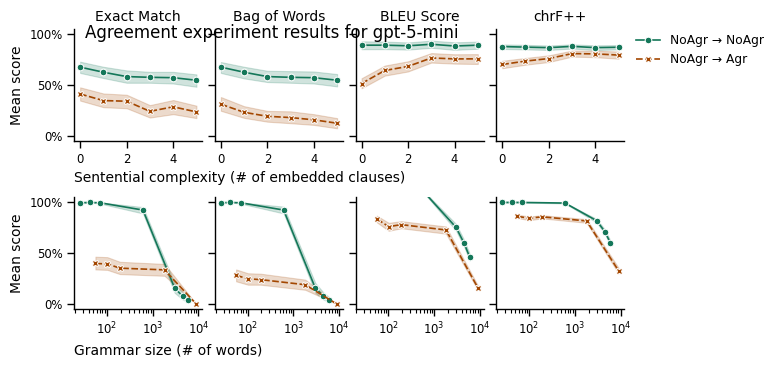

In [ ]:
if len(plot_depth_df):
    PERF_METRICS = ["Exact Match", "Bag of Words", "BLEU Score", "chrF++"]
    fig = plt.figure(
        figsize=(aes.PAPER_WIDTH_IN, aes.FIG_HEIGHT_DOUBLEROW_DIFFAXES_IN)
    )
    grid = fig.add_gridspec(2, len(PERF_METRICS), wspace=0.1, hspace=0.5)

    with sns.plotting_context("paper", font_scale=1, rc=aes.rcs):
        for r in range(2):
            for i, metric_name in enumerate(PERF_METRICS):
                ax = fig.add_subplot(grid[r, i])

                if r == 0:
                    sns.lineplot(
                        data=plot_depth_df[plot_depth_df["match_type"] == metric_name],
                        x="depth",
                        y="match_value",
                        hue="agreement_condition",
                        style="agreement_condition",
                        markers=True,
                        ax=ax,
                        palette=PALETTE_AGREEMENT,
                        legend=True,
                        errorbar="ci",
                    )
                    ax.set_xlabel(
                        "Sentential complexity (# of embedded clauses)",
                        loc="left" if i == 0 else "center",
                    )
                    # ax.set_xticks(sorted(plot_depth_df["depth"].unique()))
                else:
                    sns.lineplot(
                        data=plot_size_df[plot_size_df["match_type"] == metric_name],
                        x="n_words",
                        y="match_value",
                        hue="agreement_condition",
                        style="agreement_condition",
                        markers=True,
                        ax=ax,
                        palette=PALETTE_AGREEMENT,
                        legend=True,
                        errorbar="ci",
                    )
                    ax.set_xlabel(
                        "Grammar size (# of words)",
                        loc="left" if i == 0 else "center",
                    )
                    # ax.xaxis.set_major_formatter(aes.NICE_FORMATTER)
                    ax.set_xscale("log")
                    # ax.set_xticks(sorted(plot_size_df["n_words"].unique()))

                ax.set_ylim(-0.05, 1.05)
                ax.yaxis.set_major_formatter(aes.PCT_FORMATTER)
                ax.spines["top"].set_visible(False)
                ax.spines["right"].set_visible(False)
                if r == 0:
                    ax.set_title(metric_name)

                if i == 0:
                    ax.set_ylabel("Mean score")
                else:
                    ax.set_ylabel("")
                    ax.yaxis.set_ticklabels([])
                    if r == 0:
                        ax.set_xlabel("")
                    else:
                        ax.set_xlabel("")

                if (i == len(PERF_METRICS) - 1) and (r == 0):
                    ax.legend(
                        title="",
                        bbox_to_anchor=(1.05, 1.0),
                        loc="upper left",
                        borderaxespad=0,
                        frameon=False,
                    )
                else:
                    ax.get_legend().remove()

    # plt.suptitle(f"Agreement experiment results for {PLOT_MODEL}", x=0.02, ha="left", y=1.02)
    plt.subplots_adjust(left=0, bottom=0, right=1, top=1)
    plt.show()
else:
    print("No scored outputs available yet for plotting.")


## Ambiguous examples

In [12]:
if len(merged_df):
    ambiguous_hits = merged_df[merged_df["ambiguity_bonus"]].copy()
    cols = [
        "grammar_name",
        "sample_id",
        "agreement_condition",
        "depth",
        "left_phonetic",
        "model_answer",
        "right_phonetic",
        "reference_count",
    ]
    display(ambiguous_hits[cols].head(20))
else:
    print("No ambiguous matches to inspect yet.")


,grammar_name,sample_id,agreement_condition,depth,left_phonetic,model_answer,right_phonetic,reference_count
1692,1a27cdd22b89226b,12,NoAgr → Agr,0,numjaz biglihlec baysaywezruy xoy yen foqmew giy,fejzuldax kixzewnoz kuthoj hudnavfidzib mahrog...,fejzuldax kixzewnoz kutjol hudnavfidzib mahrog...,12.0
1694,1a27cdd22b89226b,14,NoAgr → Agr,0,nikgebpix yok rawkartiy besmexxev,worxuf huctiryeqfiz hujvaz zic,worxuf huctiryeqfiz hujvaz zichuq,12.0
1714,1a27cdd22b89226b,34,NoAgr → Agr,1,rawkartiy xoy yen foqmew mahzid biglihlec qapg...,hujvaz mahrogwod luj kixzewnoz kutjol ceb riv ...,hujvaz mahrogwod lujhuq kixzewnoz kuthoj ceb r...,72.0
1728,1a27cdd22b89226b,48,NoAgr → Agr,2,jem yiv luf kapsefpobwec yiv luf nikgebpix yok...,bacjej jikpoqfanjol nol hucmolkug jikpoqfanjol...,bacjej jikpoqfanjol nol hucmolkug jikpoqfanpec...,432.0
1737,1a27cdd22b89226b,57,NoAgr → Agr,2,cuplam xof luf nikgebpix yok luf numjaz yok ra...,zajniv jubmol lar dezpacqiw nol worxuf huctiry...,zajniv jubmol lar dezpacqiw nol worxuf huctiry...,432.0
1786,1a27cdd22b89226b,106,NoAgr → Agr,5,numjaz biglihlec qapgiq rawkartiy qum purtef l...,fejzuldax kixzewnoz kutjol ceb hujvaz jikdiqsi...,fejzuldax kixzewnoz kutjol ceb hujvaz jikdiqsi...,93312.0
1803,cb8d41a6e118b530,3,NoAgr → Agr,0,dalvughur qem quzjuz dij,wiq yoyloj lul cifgiddic qiy,wiq yoyloj lul cifgiddic qiynej,12.0
1820,cb8d41a6e118b530,20,NoAgr → Agr,1,cetvom xom ket laqbiy qewbuh don bik mif zum,tukninbeqnaz jacnev cag massoq zex sotyernev p...,tukninbeqnaz jacnev cag massoq zex sotyeryih p...,36.0
1827,cb8d41a6e118b530,27,NoAgr → Agr,1,zum qem ket qewbuh don bik mif quzjuz yet,puzyas yoyyih cag zex sotyeryih lul gagtic,puzyas yoyyih cag zex sotyeryih lul gagticnej,72.0
1831,cb8d41a6e118b530,31,NoAgr → Agr,1,kak fej xom ket dalvughur tustig laqbiy fuh hof,cal jacyih cag wiq xaryih massoq wuy sey suv,cal jacyih cag wiq xarloj massoq wuy sey suv,72.0


## Notes

- `exact_match_any` is ambiguity-aware and uses the full `possible_right_phonetic` set.
- The heuristic metrics (`Bag of Words`, `Edit Similarity`, `BLEU`, `chrF++`) are currently computed against the single canonical target string.
- The notebook still avoids materializing the giant alternative lists during the initial sample load.
- Re-run the notebook as new `*_output.jsonl` files land in `batches/agreement_exp/`.
